# Week 4 Assignment — CIFAR-10 Image Classification using ANN and CNN

This project compares a basic Artificial Neural Network with a Convolutional Neural Network for classifying CIFAR-10 images. An improved CNN with data augmentation and EarlyStopping is also trained to study how architecture and training strategies affect model performance.

## Objective

The goal is to classify CIFAR-10 images into 10 categories and compare how ANN and CNN models perform on image data. The project also explores data augmentation, deeper convolution layers, and EarlyStopping to improve generalization.

Import Libraries

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Flatten,
    Dense,
    Dropout,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    RandomFlip,
    RandomRotation,
    RandomZoom
)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPU devices: []


TensorFlow is used to build and train the neural networks. A GPU can reduce training time, especially for the CNN and augmented CNN models.

## Part 1 — Loading and Understanding CIFAR-10

### Loading the CIFAR-10 Dataset

CIFAR-10 contains 60,000 color images belonging to 10 classes. The dataset provides 50,000 images for training and 10,000 images for testing.

Part 1 — Loading and Understanding CIFAR-10

In [3]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4256s 25us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


Class Names

In [4]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 10
['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


In [5]:
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training labels shape: (50000,)
Testing labels shape: (10000,)


Display Sample Images

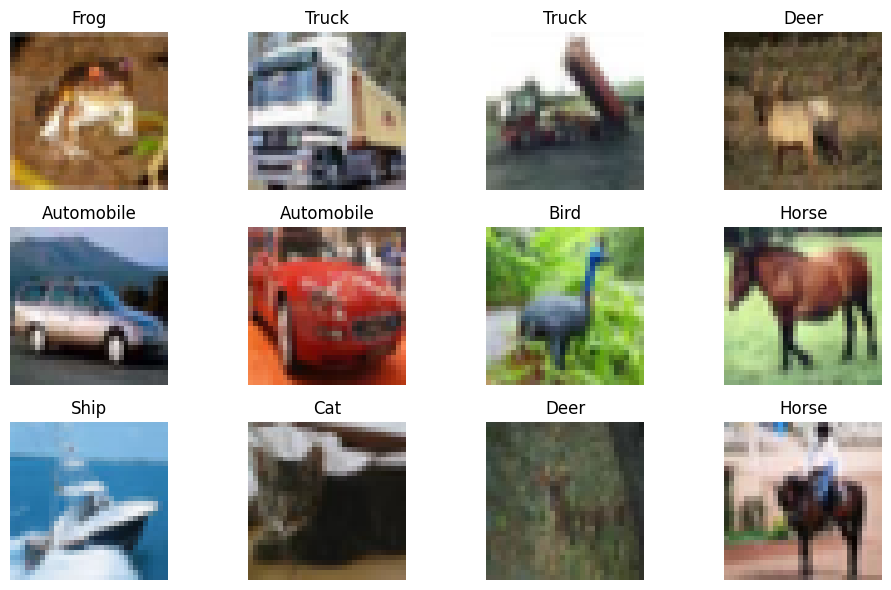

In [6]:
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

The sample images show that CIFAR-10 images are small and contain different objects such as vehicles, animals, and ships. Since the images are only 32 × 32 pixels, some classes can look visually similar.

Class Distribution

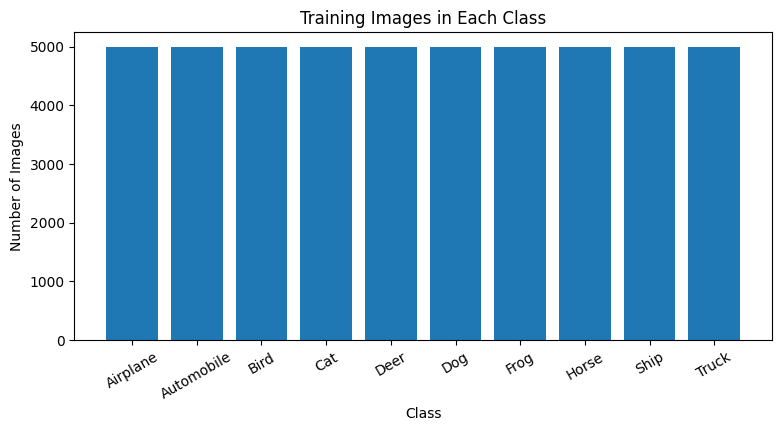

In [7]:
class_counts = np.bincount(y_train)

plt.figure(figsize=(9, 4))
plt.bar(class_names, class_counts)

plt.title("Training Images in Each Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.show()

The training dataset is balanced because every class contains the same number of images. This allows the models to learn all classes without one category dominating the training process.

## Part 2 — Image Normalization

#### Image Normalization

The original pixel values range from 0 to 255. Dividing them by 255 converts the values into the range 0 to 1, which makes neural network training more stable.

Normalize Images

In [8]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Part 3 — Baseline ANN Model

#### Baseline ANN Model

The ANN model treats every image as one long vector instead of studying its spatial structure. It provides a simple baseline that can later be compared with the CNN.

Build ANN

In [9]:
ann_model = Sequential([
    Input(shape=(32, 32, 3)),

    Flatten(),

    Dense(512, activation="relu"),
    Dropout(0.4),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(10, activation="softmax")
])

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Compile ANN

In [10]:
ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train ANN for 10 Epochs

In [11]:
ann_history = ann_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2021 - loss: 2.1163 - val_accuracy: 0.2810 - val_loss: 1.9661
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2553 - loss: 1.9856 - val_accuracy: 0.2939 - val_loss: 1.9589
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.2702 - loss: 1.9435 - val_accuracy: 0.3114 - val_loss: 1.9164
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2817 - loss: 1.9188 - val_accuracy: 0.3190 - val_loss: 1.8851
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.2892 - loss: 1.9059 - val_accuracy: 0.3194 - val_loss: 1.9051
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2933 - loss: 1.8953 - val_accuracy: 0.3439 - val_loss: 1.8612
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3020 - loss: 1.8778 - val_accuracy: 0.3506 - val_loss: 1.8516
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3073 - loss: 1.8705 - val_accu

Evaluate ANN

In [12]:
ann_test_loss, ann_test_accuracy = ann_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("ANN Test Loss:", round(ann_test_loss, 4))
print("ANN Test Accuracy:", round(ann_test_accuracy, 4))

ANN Test Loss: 1.8195
ANN Test Accuracy: 0.3441


The ANN provides a baseline result, but flattening the image removes information about nearby pixels. This limits its ability to recognize shapes and visual patterns.

ANN Training Curves

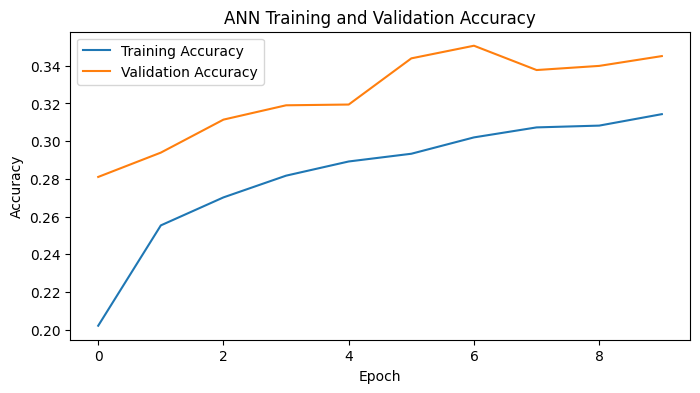

In [13]:
plt.figure(figsize=(8, 4))

plt.plot(ann_history.history["accuracy"], label="Training Accuracy")
plt.plot(ann_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Part 4 — CNN Model

#### Convolutional Neural Network

CNNs are more suitable for image classification because convolution layers learn local patterns such as edges, shapes, and textures. Pooling layers reduce image dimensions while keeping useful visual information.

Build CNN

In [14]:
cnn_model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.4),

    Dense(10, activation="softmax")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,658 (2.26 MB)

 Trainable params: 591,466 (2.26 MB)

 Non-trainable params: 192 (768.00 B)

Compile CNN

In [15]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train CNN for 10 Epochs

In [16]:
cnn_history = cnn_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.1780 - loss: 2.1017 - val_accuracy: 0.2241 - val_loss: 1.8721
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.2189 - loss: 1.9455 - val_accuracy: 0.2953 - val_loss: 1.8352
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.2748 - loss: 1.8307 - val_accuracy: 0.3911 - val_loss: 1.6162
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 69ms/step - accuracy: 0.2876 - loss: 1.7788 - val_accuracy: 0.4643 - val_loss: 1.4405
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.3154 - loss: 1.7249 - val_accuracy: 0.4802 - val_loss: 1.4304
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.3826 - loss: 1.5960 - val_accuracy: 0.5730 - val_loss: 1.2331
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.4954 - loss: 1.3421 - val_accuracy: 0.6668 - val_loss: 0.9769
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.5837 - loss: 1.1576 -

Evaluate CNN

In [17]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("CNN Test Loss:", round(cnn_test_loss, 4))
print("CNN Test Accuracy:", round(cnn_test_accuracy, 4))

CNN Test Loss: 0.9588
CNN Test Accuracy: 0.6733


The CNN is expected to perform better than the ANN because it preserves spatial relationships between pixels. This helps the model identify visual patterns more effectively.

## Part 5 — ANN vs CNN Validation Accuracy

#### ANN and CNN Comparison

The validation accuracy curves show how both models improve during training. Comparing them helps understand which architecture learns image features more effectively.

Combined Validation Accuracy Chart

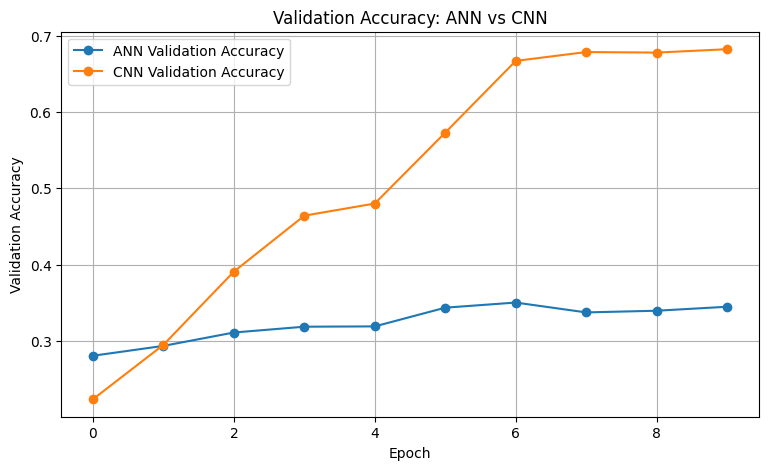

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    ann_history.history["val_accuracy"],
    marker="o",
    label="ANN Validation Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    marker="o",
    label="CNN Validation Accuracy"
)

plt.title("Validation Accuracy: ANN vs CNN")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Part 6 — Advanced Data-Augmented CNN

#### Data Augmentation

Data augmentation creates slightly modified versions of training images. Random flipping, rotation, and zoom help the model learn more general visual patterns and reduce overfitting.

Augmentation Layers

In [19]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
], name="data_augmentation")

Show Augmented Images

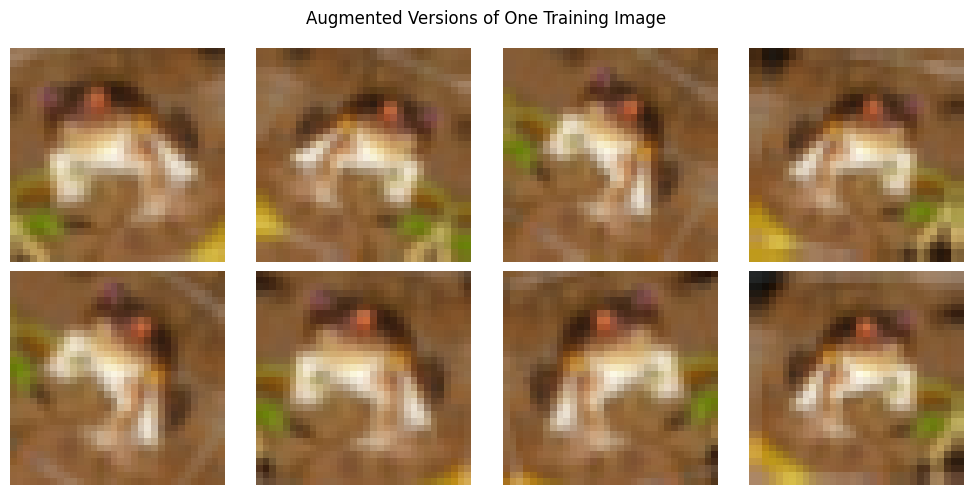

In [20]:
sample_image = x_train[0]

plt.figure(figsize=(10, 5))

for i in range(8):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(augmented_image[0])
    plt.axis("off")

plt.suptitle("Augmented Versions of One Training Image")
plt.tight_layout()
plt.show()

The transformed images keep the same object but change its orientation or scale. This gives the model more variety without requiring additional labelled images.

Improved Architecture

#### Improved CNN Architecture

The improved CNN increases filter sizes from 32 to 64 and then 128. Deeper convolution blocks allow the model to learn simple patterns first and more complex image features in later layers.

Build Improved CNN

In [21]:
augmented_cnn = Sequential([
    Input(shape=(32, 32, 3)),

    data_augmentation,

    Conv2D(32, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Conv2D(128, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.35),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

augmented_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 846,634 (3.23 MB)

 Trainable params: 846,186 (3.23 MB)

 Non-trainable params: 448 (1.75 KB)

Compile Improved CNN

In [22]:
augmented_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#### EarlyStopping



Training for more epochs may improve performance, but it can also cause overfitting. EarlyStopping watches validation loss and stops training when the model no longer improves, while restoring the best weights.

EarlyStopping Callback

In [23]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

Train Improved CNN for 20 Epochs

In [24]:
augmented_history = augmented_cnn.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 191ms/step - accuracy: 0.2306 - loss: 2.0394 - val_accuracy: 0.2799 - val_loss: 1.9740
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 122s 196ms/step - accuracy: 0.3286 - loss: 1.7574 - val_accuracy: 0.3841 - val_loss: 1.6578
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 136s 218ms/step - accuracy: 0.4000 - loss: 1.6077 - val_accuracy: 0.3832 - val_loss: 1.7194
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 124ms/step - accuracy: 0.4581 - loss: 1.4777 - val_accuracy: 0.4799 - val_loss: 1.5026
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.5105 - loss: 1.3752 - val_accuracy: 0.4965 - val_loss: 1.4330
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.5449 - loss: 1.2995 - val_accuracy: 0.6009 - val_loss: 1.1559
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.5661 - loss: 1.2350 - val_accuracy: 0.5332 - val_loss: 1.4376
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.5870 - loss: 



The model stopped training automatically after 13 epochs because the validation loss was no longer improving. The best performance was achieved at Epoch 9, so those weights were restored. This helped prevent overfitting and ensured that the final model used its best learned parameters.

Evaluate Improved CNN

In [25]:
aug_test_loss, aug_test_accuracy = augmented_cnn.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Augmented CNN Test Loss:", round(aug_test_loss, 4))
print("Augmented CNN Test Accuracy:", round(aug_test_accuracy, 4))

Augmented CNN Test Loss: 0.9981
Augmented CNN Test Accuracy: 0.6562


Improved CNN Curves

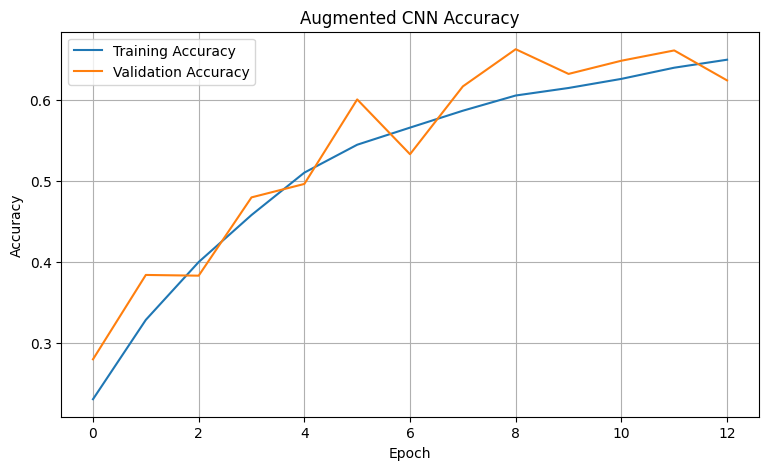

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    augmented_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    augmented_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Augmented CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Validation Loss

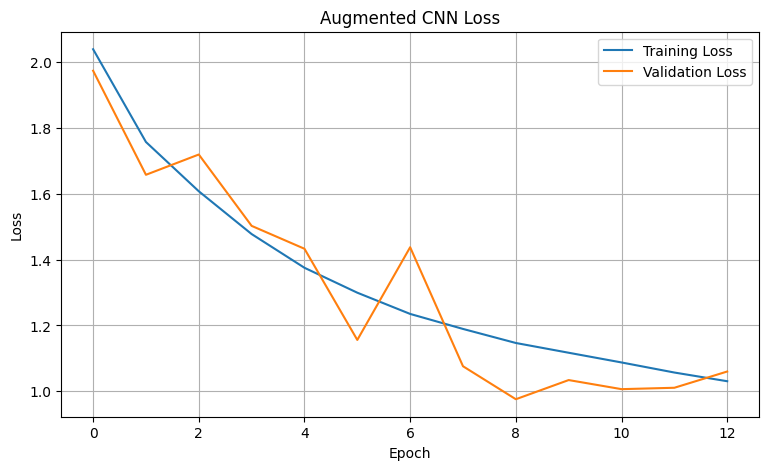

In [27]:
plt.figure(figsize=(9, 5))

plt.plot(
    augmented_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    augmented_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Augmented CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()



## Part 7 — Final Model Comparison

#### Final Model Comparison

The final comparison shows how model architecture and training strategy affect image classification performance. Test accuracy provides a fair comparison because the test images were not used during training.

Comparison Table

In [28]:
model_results = pd.DataFrame({
    "Model": [
        "Baseline ANN",
        "CNN",
        "Augmented CNN"
    ],
    "Test Loss": [
        ann_test_loss,
        cnn_test_loss,
        aug_test_loss
    ],
    "Test Accuracy": [
        ann_test_accuracy,
        cnn_test_accuracy,
        aug_test_accuracy
    ]
})

model_results["Test Loss"] = model_results["Test Loss"].round(4)
model_results["Test Accuracy"] = model_results["Test Accuracy"].round(4)

display(model_results)

,Model,Test Loss,Test Accuracy
0,Baseline ANN,1.8195,0.3441
1,CNN,0.9588,0.6733
2,Augmented CNN,0.9981,0.6562


Accuracy Comparison Chart

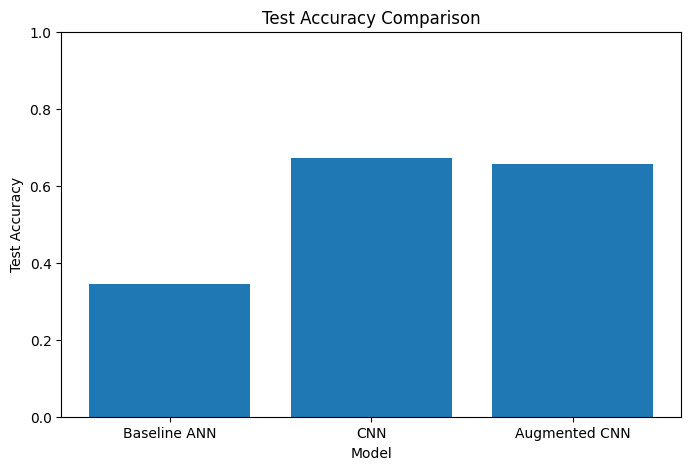

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["Test Accuracy"]
)

plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

plt.show()

## Part 8 — Prediction Analysis

Generate Predictions

In [30]:
prediction_probabilities = augmented_cnn.predict(
    x_test,
    verbose=0
)

predicted_labels = np.argmax(
    prediction_probabilities,
    axis=1
)

Classification Report

In [31]:
print(
    classification_report(
        y_test,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.75      0.70      0.73      1000
  Automobile       0.86      0.82      0.84      1000
        Bird       0.74      0.29      0.42      1000
         Cat       0.45      0.45      0.45      1000
        Deer       0.69      0.41      0.52      1000
         Dog       0.60      0.56      0.58      1000
        Frog       0.50      0.88      0.63      1000
       Horse       0.74      0.75      0.74      1000
        Ship       0.78      0.85      0.81      1000
       Truck       0.64      0.85      0.73      1000

    accuracy                           0.66     10000
   macro avg       0.68      0.66      0.65     10000
weighted avg       0.68      0.66      0.65     10000



Confusion Matrix

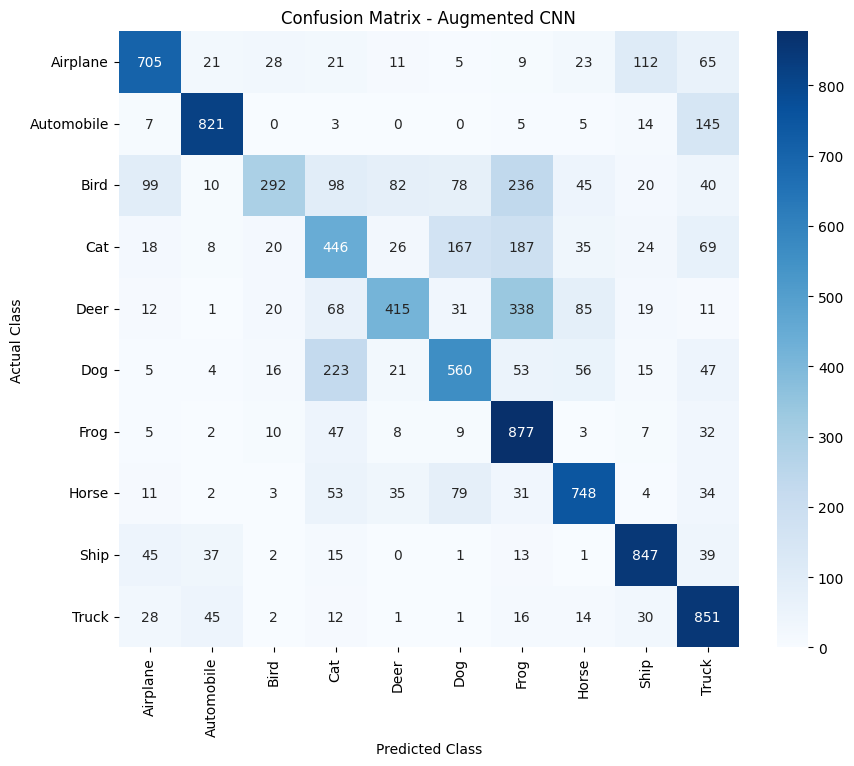

In [35]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Augmented CNN")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

Display Predictions

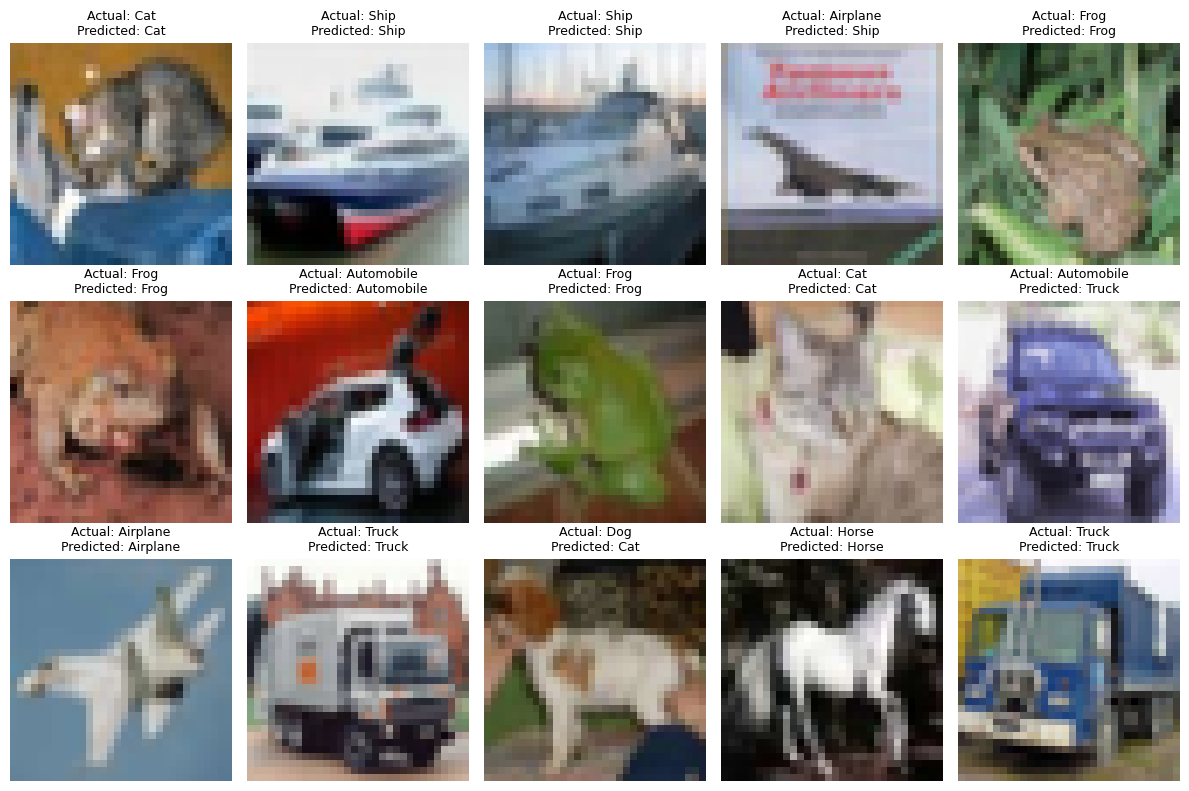

In [33]:
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[y_test[i]]
    predicted = class_names[predicted_labels[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Observations



- The ANN was able to classify the images, but its accuracy was lower because it treated every image as a flat vector and could not capture image patterns.

- The CNN performed better than the ANN since the convolution layers learned important features such as edges, textures, and shapes directly from the images.

- Increasing the number of filters from 32 to 64 and then 128 helped the improved CNN learn more detailed features, which resulted in better overall performance.

- Data augmentation created different versions of the training images by flipping, rotating, and zooming them. This helped the model generalize better instead of simply memorizing the training data.

- EarlyStopping stopped the training once the validation performance stopped improving, which helped reduce overfitting and saved training time.

- Some classes, such as cats and dogs or trucks and automobiles, were still confused in a few cases because the CIFAR-10 images are very small (32×32 pixels) and some objects have similar visual features.

## Final Conclusion

This project showed how different deep learning models perform on the same image classification task. The ANN worked as a good baseline, while the CNN achieved better results by learning image features directly through convolution layers.

The improved CNN, along with data augmentation and EarlyStopping, produced the best performance. Overall, the project demonstrates that choosing the right architecture and training strategy plays an important role in building an accurate image classification model.